In [1]:
!pip install tensorflow numpy matplotlib seaborn scikit-learn

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

IMAGE_SIZE = (32, 32, 3)
NUM_CLASSES = 10
EPOCHS = 15
BATCH_SIZE = 64

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = y_train.flatten()
y_test  = y_test.flatten()

print(f"Training samples : {len(x_train):,}")
print(f"Test samples     : {len(x_test):,}")
print(f"Image shape      : {x_train.shape[1:]}")
print(f"Classes          : {CLASS_NAMES}")

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training samples : 50,000
Test samples     : 10,000
Image shape      : (32, 32, 3)
Classes          : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation="relu",
                               padding="same", input_shape=IMAGE_SIZE),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    return model

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
]

print("Training started... this takes 5-15 minutes on GPU")
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)
print("Training complete!")
final_acc = max(history.history["val_accuracy"])
print(f"Best validation accuracy: {final_acc:.1%}")

Training started... this takes 5-15 minutes on GPU
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.3844 - loss: 1.7270 - val_accuracy: 0.5316 - val_loss: 1.3011 - learning_rate: 0.0010
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5077 - loss: 1.3718 - val_accuracy: 0.5834 - val_loss: 1.1975 - learning_rate: 0.0010
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5734 - loss: 1.2048 - val_accuracy: 0.6439 - val_loss: 1.0152 - learning_rate: 0.0010
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6144 - loss: 1.0973 - val_accuracy: 0.6420 - val_loss: 1.0076 - learning_rate: 0.0010
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6449 - loss: 1.0151 - val_accuracy: 0.5316 - val_loss: 1.5543 - learning_rate: 0.0010
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6642 - loss: 0.9583 - val_accuracy: 0.7088 - val_loss: 0.8444 - learning_rate: 0.0010
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━

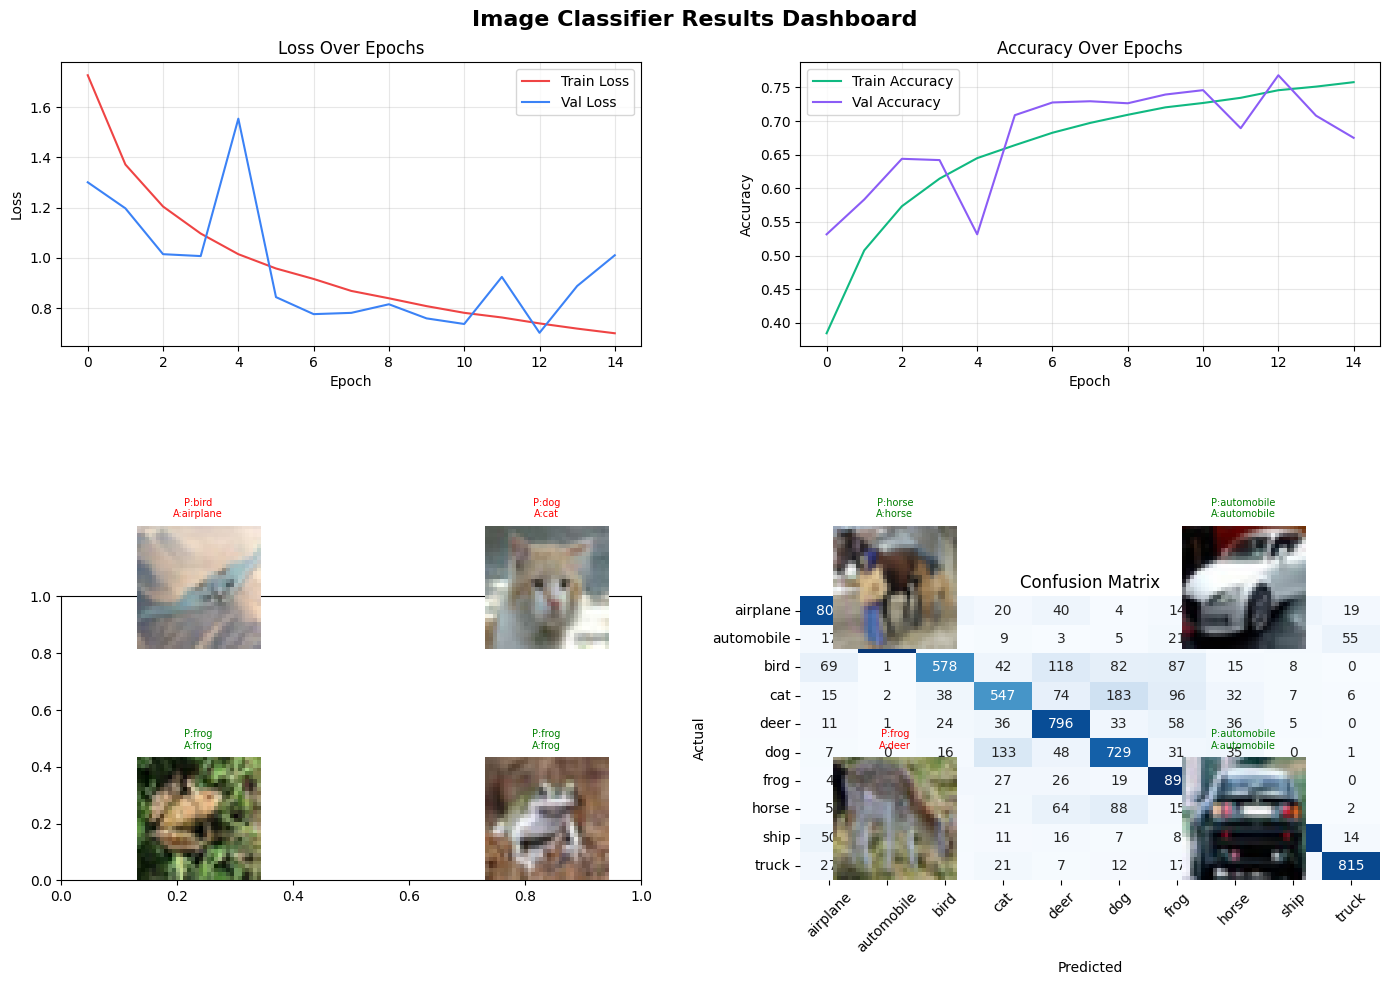

Dashboard saved!

              precision    recall  f1-score   support

    airplane       0.80      0.80      0.80      1000
  automobile       0.90      0.87      0.89      1000
        bird       0.77      0.58      0.66      1000
         cat       0.63      0.55      0.59      1000
        deer       0.67      0.80      0.73      1000
         dog       0.63      0.73      0.67      1000
        frog       0.72      0.90      0.80      1000
       horse       0.84      0.79      0.81      1000
        ship       0.90      0.86      0.88      1000
       truck       0.89      0.81      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Image Classifier Results Dashboard", fontsize=16, fontweight="bold")

axes[0,0].plot(history.history["loss"], label="Train Loss", color="#ef4444")
axes[0,0].plot(history.history["val_loss"], label="Val Loss", color="#3b82f6")
axes[0,0].set_title("Loss Over Epochs")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(history.history["accuracy"], label="Train Accuracy", color="#10b981")
axes[0,1].plot(history.history["val_accuracy"], label="Val Accuracy", color="#8b5cf6")
axes[0,1].set_title("Accuracy Over Epochs")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Accuracy")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1,1], cbar=False)
axes[1,1].set_title("Confusion Matrix")
axes[1,1].set_xlabel("Predicted")
axes[1,1].set_ylabel("Actual")
axes[1,1].tick_params(axis="x", rotation=45)

sample_indices = np.random.choice(len(x_test), 8, replace=False)
for i, idx in enumerate(sample_indices):
    ax = plt.subplot(4, 4, 9 + i)
    img = x_test[idx]
    pred = np.argmax(model.predict(np.expand_dims(img, 0), verbose=0))
    actual = y_test[idx]
    color = "green" if pred == actual else "red"
    ax.imshow(img)
    ax.set_title(f"P:{CLASS_NAMES[pred]}\nA:{CLASS_NAMES[actual]}",
                 fontsize=7, color=color)
    ax.axis("off")

plt.tight_layout()
plt.savefig("results_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved!")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))